# ISMN Soil Moisture — Station Presence & Density by CEC Ecoregion

Uses the local CEC North-American ecoregion shapefiles in `ISMN_dataset/ecoregions/` at **Levels II and III** (e.g. `13.1` and `13.1.3`). Each region with stations is coloured with a distinct hue from a large qualitative palette; regions with no stations are grey. A final cell maps **station density** (stations per 10 000 km²).

In [10]:
from __future__ import annotations

import colorsys
import math
from pathlib import Path

import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── paths ───────────────────────────────────────────────────────────────
ROOT     = Path(".")
CSV_PATH = ROOT / "ISMN_dataset" / "sm_station_month_means.csv"
ECO_L3   = ROOT / "ISMN_dataset" / "ecoregions" / "l3" / "NA_CEC_Eco_Level3.shp"

# ── user-facing knobs ───────────────────────────────────────────────────
MONTH    = None
EXTENT   = (-125.0, -66.5, 24.0, 50.0)   # CONUS lon/lat box
DOT_SIZE = 9
OUTPUT   = ROOT / "visualize_ISMN_ecoregions.png"

# CRS used for area calculations (CONUS Albers Equal-Area, metres)
EQUAL_AREA_CRS = "EPSG:5070"

# Only Levels II and III — Level II codes look like "13.1",
# Level III codes look like "13.1.3".
LEVELS = [
    {"key": "II",  "code": "NA_L2CODE", "name": "NA_L2NAME", "label": "Level II"},
    {"key": "III", "code": "NA_L3CODE", "name": "NA_L3NAME", "label": "Level III"},
]

## 1 · Load ISMN station data

In [11]:
def load_ismn_points(csv_path: Path, month: str | None = None) -> pd.DataFrame:
    required = ["station_month_mean", "lat", "lon"]
    if month:
        required.append("month")
    df = pd.read_csv(csv_path, usecols=lambda c: c in set(required))
    missing = sorted(set(required) - set(df.columns))
    if missing:
        raise ValueError(f"{csv_path} is missing required columns: {', '.join(missing)}")
    if month:
        df = df[df["month"] == month]
    df = df.dropna(subset=["station_month_mean", "lat", "lon"])
    df = df[(df["lat"].between(-90, 90)) & (df["lon"].between(-180, 180))]
    return df[["lat", "lon"]].drop_duplicates().reset_index(drop=True)


points = load_ismn_points(CSV_PATH, month=MONTH)
print(f"Loaded {len(points):,} unique ISMN station locations")

points_gdf = gpd.GeoDataFrame(
    points,
    geometry=gpd.points_from_xy(points["lon"], points["lat"]),
    crs="EPSG:4326",
)
points_gdf.head()

Loaded 965 unique ISMN station locations


,lat,lon,geometry
0,44.91670,-68.73590,POINT (-68.7359 44.9167)
1,35.67920,-105.82690,POINT (-105.8269 35.6792)
2,40.17179,-103.22248,POINT (-103.22248 40.17179)
3,43.00177,-119.95179,POINT (-119.95179 43.00177)
4,36.42028,-105.29365,POINT (-105.29365 36.42028)


## 2 · Load CEC ecoregion shapefile (local)

The Level III file already carries Level II codes (its `NA_L2CODE` parent column), so both levels are derived by dissolving the same file on the appropriate code column.

In [12]:
if not ECO_L3.exists():
    raise FileNotFoundError(
        f"Expected CEC Level-III shapefile at {ECO_L3}. "
        "Make sure ISMN_dataset/ecoregions/l3/ is populated."
    )

eco_l3 = gpd.read_file(ECO_L3).to_crs("EPSG:4326")
print(f"L3 polygons: {len(eco_l3):,}")
print(f"columns: {eco_l3.columns.tolist()}")

L3 polygons: 2,548
columns: ['NA_L3CODE', 'NA_L3NAME', 'NA_L2CODE', 'NA_L2NAME', 'NA_L1CODE', 'NA_L1NAME', 'NA_L3KEY', 'NA_L2KEY', 'NA_L1KEY', 'Shape_Leng', 'Shape_Area', 'geometry']


## 3 · Spatial join — assign each station to an ecoregion

In [13]:
level_cols = ["NA_L1CODE", "NA_L2CODE", "NA_L3CODE"]

joined = gpd.sjoin(
    points_gdf,
    eco_l3[[*level_cols, "geometry"]],
    how="left",
    predicate="within",
)
matched = joined["NA_L3CODE"].notna().sum()
print(f"Stations matched by 'within': {matched:,} / {len(joined):,}")

unmatched_mask = joined["NA_L3CODE"].isna()
if unmatched_mask.any():
    # Project both sides to an equal-area CRS so 'nearest' distances are meaningful.
    pts_proj = points_gdf[unmatched_mask].to_crs(EQUAL_AREA_CRS)
    eco_proj = eco_l3[[*level_cols, "geometry"]].to_crs(EQUAL_AREA_CRS)
    fallback = gpd.sjoin_nearest(
        pts_proj, eco_proj, how="left", max_distance=50_000,  # 50 km
    )
    for col in level_cols:
        joined.loc[unmatched_mask, col] = fallback[col].values
    print(f"Recovered {unmatched_mask.sum()} unmatched stations via nearest-join (≤50 km)")
    print(f"Final matched: {joined['NA_L3CODE'].notna().sum():,} / {len(joined):,}")

Stations matched by 'within': 937 / 965
Recovered 28 unmatched stations via nearest-join (≤50 km)
Final matched: 937 / 965


## 4 · Build per-level dissolved GeoDataFrames with station counts & areas

In [ ]:
eco_l3_proj = eco_l3.to_crs(EQUAL_AREA_CRS)


def build_level_gdf(level_cfg: dict) -> gpd.GeoDataFrame:
    code_col = level_cfg["code"]
    name_col = level_cfg["name"]

    keep_cols = [code_col, name_col, "geometry"]
    dissolved = eco_l3.dissolve(by=code_col, as_index=False)[keep_cols]

    # Equal-area dissolve for accurate region areas (km²)
    area_km2 = (
        eco_l3_proj.dissolve(by=code_col, as_index=False)
        .assign(area_km2=lambda g: g.geometry.area / 1e6)
        [[code_col, "area_km2"]]
    )
    dissolved = dissolved.merge(area_km2, on=code_col, how="left")

    counts = (
        joined[joined[code_col].notna()]
        .groupby(code_col)
        .size()
        .reset_index(name="station_count")
    )
    dissolved = dissolved.merge(counts, on=code_col, how="left")
    dissolved["station_count"] = dissolved["station_count"].fillna(0).astype(int)
    dissolved["has_stations"]  = dissolved["station_count"] > 0
    # Density: stations per 10 000 km² (≈ a typical Level-III region)
    dissolved["density_per_10k_km2"] = (
        dissolved["station_count"] / dissolved["area_km2"] * 10_000
    )
    return dissolved


level_gdfs = {cfg["key"]: build_level_gdf(cfg) for cfg in LEVELS}

print(f"{'Level':<8} {'Regions':>8} {'With stations':>15} {'Coverage':>10}")
print("-" * 45)
for lvl, gdf in level_gdfs.items():
    total   = len(gdf)
    covered = int(gdf["has_stations"].sum())
    print(f"{lvl:<8} {total:>8,} {covered:>15,} {100*covered/total:>9.1f}%")

## 5 · Diverse-colour palette generator

Combines five qualitative colormaps (`tab20`, `tab20b`, `tab20c`, `Set3`, `Paired`), dedupes near-duplicates, and tops up with golden-ratio HSV sampling so every region gets a visually distinct colour — even Level III, which has ~180 regions.

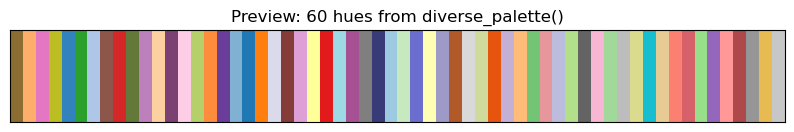

In [ ]:
def diverse_palette(n: int, seed: int = 7) -> list:
    """Return *n* visually distinct RGBA colours."""
    base_maps = ["tab20", "tab20b", "tab20c", "Set3", "Paired"]
    colours: list = []
    for cmap_name in base_maps:
        cmap = plt.get_cmap(cmap_name)
        colours.extend(cmap(i) for i in range(cmap.N))

    # Drop near-duplicates (compare in RGB) so the palette stays expressive
    deduped: list = []
    for c in colours:
        rgb = np.asarray(c[:3])
        if not any(np.linalg.norm(rgb - np.asarray(d[:3])) < 0.06 for d in deduped):
            deduped.append(c)

    # Top up with golden-angle HSV sampling for arbitrary n
    phi = 0.61803398875
    h = 0.0
    while len(deduped) < n:
        h = (h + phi) % 1.0
        s = 0.55 + 0.35 * ((len(deduped) * 7) % 5) / 5
        v = 0.70 + 0.25 * ((len(deduped) * 3) % 4) / 4
        deduped.append((*colorsys.hsv_to_rgb(h, s, v), 1.0))

    rng = np.random.default_rng(seed)
    idx = np.arange(len(deduped))
    rng.shuffle(idx)
    return [deduped[i] for i in idx[:n]]


# Quick sanity preview
_sample = diverse_palette(60)
fig, ax = plt.subplots(figsize=(10, 1.2))
ax.imshow([_sample], aspect="auto")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Preview: 60 hues from diverse_palette()")
plt.show()

## 6 · Visualise both ecoregion levels

Saved visualize_ISMN_ecoregions.png


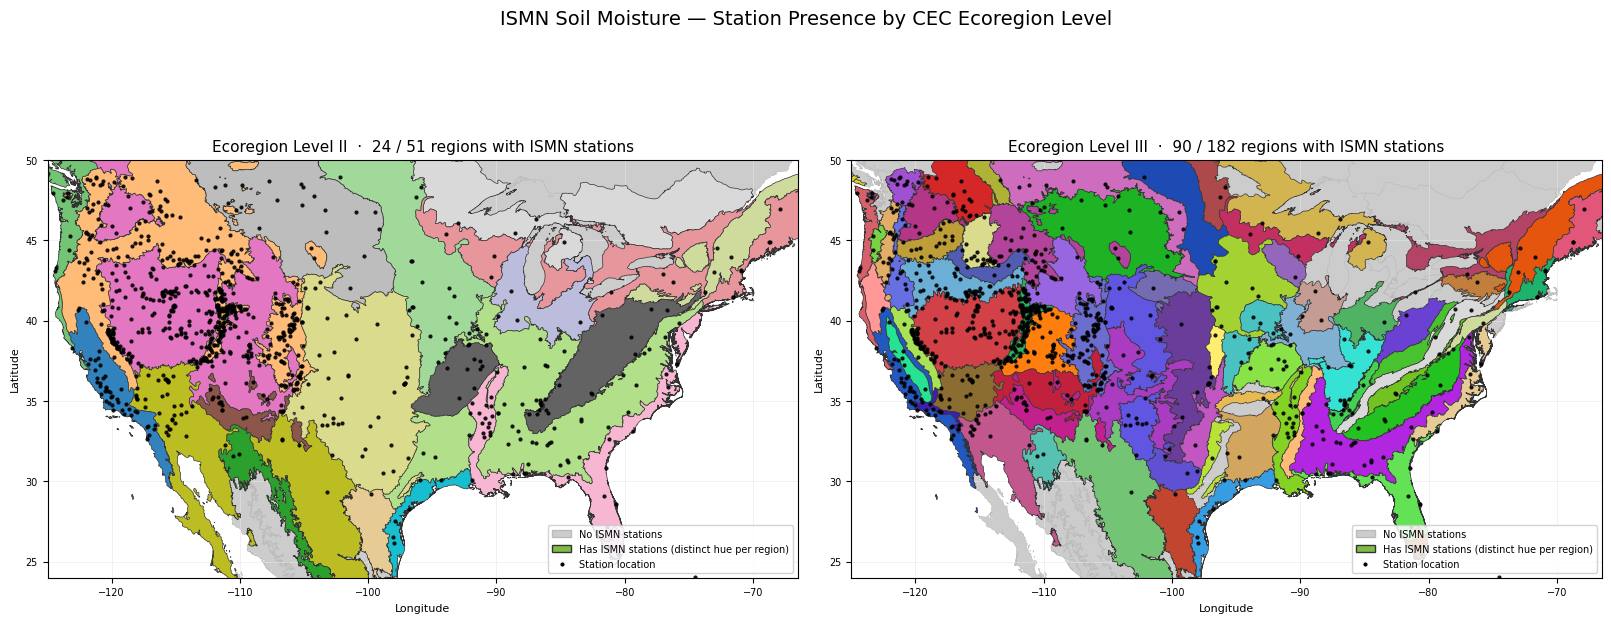

In [ ]:
def _set_extent(ax):
    lon_min, lon_max, lat_min, lat_max = EXTENT
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    center_lat = (lat_min + lat_max) / 2.0
    ax.set_aspect(1.0 / max(0.2, abs(math.cos(math.radians(center_lat)))))


def _region_colors(gdf, code_col):
    codes = sorted(gdf[code_col].unique())
    return dict(zip(codes, diverse_palette(len(codes))))


def plot_level(ax, level_cfg: dict) -> None:
    key      = level_cfg["key"]
    label    = level_cfg["label"]
    code_col = level_cfg["code"]
    gdf      = level_gdfs[key]

    color_map = _region_colors(gdf, code_col)

    no_stn  = gdf[~gdf["has_stations"]]
    has_stn = gdf[gdf["has_stations"]]

    if not no_stn.empty:
        no_stn.plot(ax=ax, color="#cccccc", edgecolor="#bbbbbb",
                    linewidth=0.4, zorder=1, aspect=None)

    if not has_stn.empty:
        colors = [color_map[c] for c in has_stn[code_col]]
        has_stn.plot(ax=ax, color=colors, edgecolor="#333333",
                     linewidth=0.5, zorder=2, aspect=None)

    ax.scatter(
        points_gdf.geometry.x, points_gdf.geometry.y,
        s=DOT_SIZE, c="black", marker="o", linewidths=0, alpha=0.9, zorder=3,
    )

    _set_extent(ax)

    covered = int(gdf["has_stations"].sum())
    total   = len(gdf)
    ax.set_title(
        f"Ecoregion {label}  ·  {covered} / {total} regions with ISMN stations",
        fontsize=11,
    )
    ax.set_xlabel("Longitude", fontsize=8)
    ax.set_ylabel("Latitude", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, color="0.90", linewidth=0.4, zorder=0)

    legend_handles = [
        mpatches.Patch(facecolor="#cccccc", edgecolor="#bbbbbb", label="No ISMN stations"),
        mpatches.Patch(facecolor="#7fbc41", edgecolor="#333333",
                       label="Has ISMN stations (distinct hue per region)"),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="black",
                   markersize=4, label="Station location"),
    ]
    ax.legend(handles=legend_handles, loc="lower right", fontsize=7, framealpha=0.85)


fig, axes = plt.subplots(1, len(LEVELS), figsize=(16, 7), constrained_layout=True)

for ax, cfg in zip(axes, LEVELS):
    plot_level(ax, cfg)

suptitle = "ISMN Soil Moisture — Station Presence by CEC Ecoregion Level"
if MONTH:
    suptitle += f"  ({MONTH})"
fig.suptitle(suptitle, fontsize=14)

fig.savefig(OUTPUT, dpi=150, bbox_inches="tight")
print(f"Saved {OUTPUT}")
plt.show()

## 7 · Station **density** per region (stations per 10 000 km²)

Counts alone are biased toward larger regions. Dividing by polygon area (computed in CONUS-Albers equal-area projection) gives a fairer picture of how thoroughly each ecoregion is sampled.

Saved visualize_ISMN_density.png


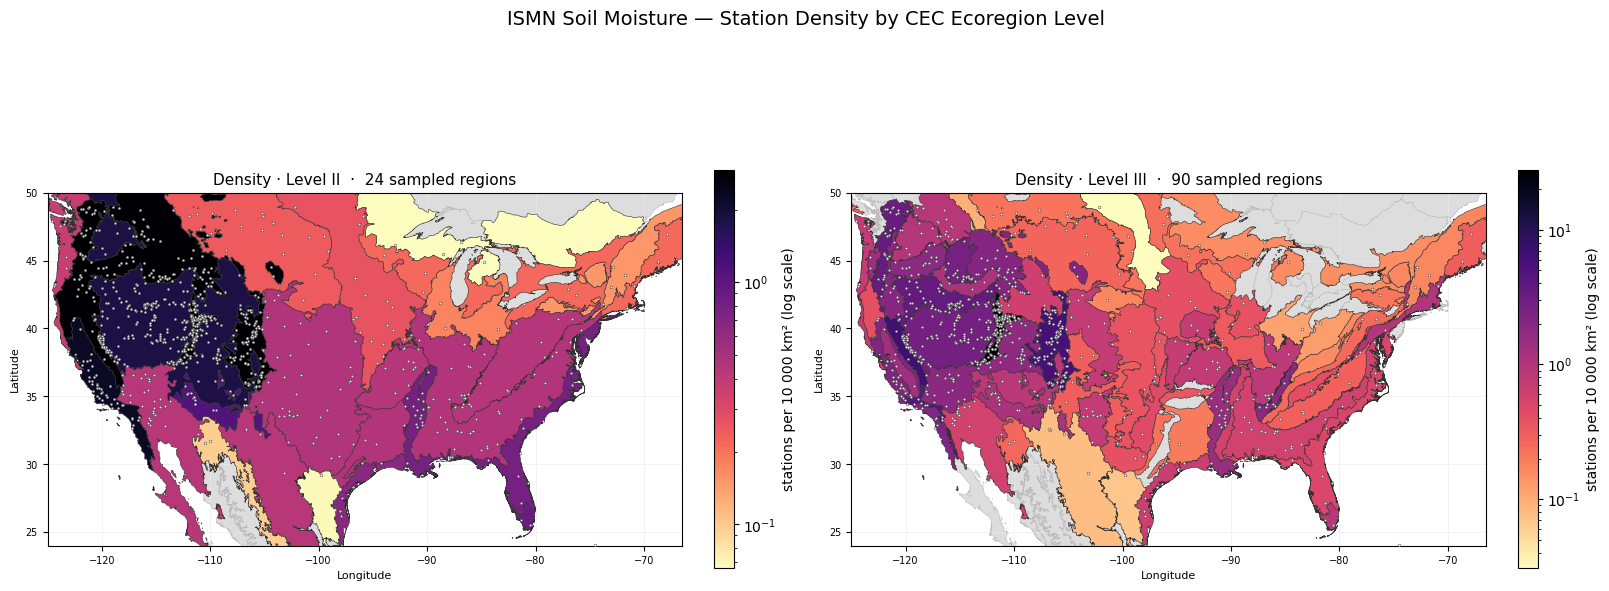


=== Level II · top 10 by station density ===
NA_L2CODE                                             NA_L2NAME  station_count     area_km2  density_per_10k_km2
      6.2                                    WESTERN CORDILLERA            369 1.265433e+06             2.915999
     11.1                              MEDITERRANEAN CALIFORNIA             43 1.900755e+05             2.262259
     10.1                                          COLD DESERTS            194 1.060076e+06             1.830058
     13.1                                  UPPER GILA MOUNTAINS             12 1.088399e+05             1.102536
     15.4                                            EVERGLADES              2 2.253339e+04             0.887572
      8.5 MISSISSIPPI ALLUVIAL AND SOUTHEAST USA COASTAL PLAINS             28 3.503173e+05             0.799275
      9.5                         TEXAS-LOUISIANA COASTAL PLAIN              6 9.083459e+04             0.660541
      9.4                       SOUTH CENTRAL SEMI

In [ ]:
def plot_density(ax, level_cfg: dict, cmap_name: str = "magma_r") -> None:
    key      = level_cfg["key"]
    label    = level_cfg["label"]
    gdf      = level_gdfs[key]

    no_stn  = gdf[~gdf["has_stations"]]
    has_stn = gdf[gdf["has_stations"]].copy()

    if not no_stn.empty:
        no_stn.plot(ax=ax, color="#dddddd", edgecolor="#bbbbbb",
                    linewidth=0.4, zorder=1, aspect=None)

    if not has_stn.empty:
        # Log-scale densities so dense + sparse regions are both legible
        vals = has_stn["density_per_10k_km2"].to_numpy()
        norm = mcolors.LogNorm(vmin=max(vals.min(), 1e-3), vmax=vals.max())
        has_stn.plot(
            ax=ax, column="density_per_10k_km2", cmap=cmap_name, norm=norm,
            edgecolor="#333333", linewidth=0.4, zorder=2, aspect=None,
            legend=True,
            legend_kwds={
                "label": "stations per 10 000 km² (log scale)",
                "shrink": 0.6,
            },
        )

    ax.scatter(
        points_gdf.geometry.x, points_gdf.geometry.y,
        s=4, c="white", marker="o", linewidths=0.3, edgecolors="black",
        alpha=0.85, zorder=3,
    )

    _set_extent(ax)
    n_with = int(gdf["has_stations"].sum())
    ax.set_title(
        f"Density · {label}  ·  {n_with} sampled regions",
        fontsize=11,
    )
    ax.set_xlabel("Longitude", fontsize=8)
    ax.set_ylabel("Latitude", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, color="0.92", linewidth=0.4, zorder=0)


fig_d, axes_d = plt.subplots(1, len(LEVELS), figsize=(16, 7), constrained_layout=True)
for ax, cfg in zip(axes_d, LEVELS):
    plot_density(ax, cfg)

fig_d.suptitle(
    "ISMN Soil Moisture — Station Density by CEC Ecoregion Level",
    fontsize=14,
)
density_out = ROOT / "visualize_ISMN_density.png"
fig_d.savefig(density_out, dpi=150, bbox_inches="tight")
print(f"Saved {density_out}")
plt.show()

# Top-density tables
for cfg in LEVELS:
    key, code_col, name_col = cfg["key"], cfg["code"], cfg["name"]
    g = level_gdfs[key]
    top = (
        g[g["has_stations"]][[code_col, name_col, "station_count", "area_km2", "density_per_10k_km2"]]
        .sort_values("density_per_10k_km2", ascending=False)
        .head(25)
        .reset_index(drop=True)
    )
    print(f"\n=== {cfg['label']} · top 10 by station density ===")
    print(top.to_string(index=False))

## 8 · Highlighted ecoregions

Zoom in on four ecoregions of interest. Codes with two dots are Level III; codes with one dot are Level II. The highlighted region is filled with a vivid colour, neighbouring regions are light grey, and ISMN stations inside the region are drawn as red dots.

- `6.2.13` — Wasatch and Uinta Mountains (L3)
- `8.3.5` — Southeastern Plains (L3)
- `11.1.1` — California Coastal Sage, Chaparral, and Oak Woodlands (L3) — assumed correction for the requested `11.11.1`, which is not a valid CEC code
- `9.4` — South Central Semiarid Prairies (L2)

In [ ]:
HIGHLIGHTS = ["6.2.13", "8.3.5", "11.1.1", "9.4"]
HIGHLIGHT_COLOURS = ["#e6194B", "#3cb44b", "#4363d8", "#f58231"]


def _lookup_region(code: str):
    """Return (level_key, level_gdf_row, level_cfg) for an L2 or L3 code."""
    dots = code.count(".")
    if dots == 2:
        key = "III"
    elif dots == 1:
        key = "II"
    else:
        raise ValueError(f"Unrecognised code format: {code!r}")
    cfg = next(c for c in LEVELS if c["key"] == key)
    gdf = level_gdfs[key]
    match = gdf[gdf[cfg["code"]] == code]
    if match.empty:
        return None
    return key, match.iloc[0], cfg


def plot_highlight(ax, code: str, fill_colour: str) -> None:
    found = _lookup_region(code)
    if found is None:
        ax.set_title(f"{code} · NOT FOUND", fontsize=12, color="crimson")
        ax.set_axis_off()
        return
    key, row, cfg = found
    level_gdf = level_gdfs[key]
    region_gdf = gpd.GeoDataFrame([row], geometry="geometry", crs=level_gdf.crs)

    # Buffer the region's bbox for context (~1.5° padding)
    minx, miny, maxx, maxy = region_gdf.total_bounds
    pad_x = max(1.5, 0.20 * (maxx - minx))
    pad_y = max(1.5, 0.20 * (maxy - miny))
    bbox = (minx - pad_x, maxx + pad_x, miny - pad_y, maxy + pad_y)

    # Context: all other regions at this level
    others = level_gdf[level_gdf[cfg["code"]] != code]
    others.plot(ax=ax, color="#eeeeee", edgecolor="#bbbbbb",
                linewidth=0.4, zorder=1, aspect=None)

    region_gdf.plot(ax=ax, color=fill_colour, edgecolor="#222222",
                    linewidth=1.4, zorder=2, aspect=None, alpha=0.88)

    # Which stations fall in this region?
    in_region = joined[joined[cfg["code"]] == code]
    out_region = joined[joined[cfg["code"]] != code]

    ax.scatter(out_region.geometry.x, out_region.geometry.y,
               s=5, c="#888888", marker="o", linewidths=0, alpha=0.4, zorder=3)
    ax.scatter(in_region.geometry.x, in_region.geometry.y,
               s=34, c="#e6194B", marker="o", linewidths=0.6,
               edgecolors="black", zorder=4)

    ax.set_xlim(bbox[0], bbox[1])
    ax.set_ylim(bbox[2], bbox[3])
    center_lat = (bbox[2] + bbox[3]) / 2.0
    ax.set_aspect(1.0 / max(0.2, abs(math.cos(math.radians(center_lat)))))

    name    = row[cfg["name"]]
    n_stn   = int(row["station_count"])
    area    = row["area_km2"]
    density = row["density_per_10k_km2"]
    ax.set_title(
        f"{code} · {name}\n"
        f"Level {key} · {n_stn} stations · {area:,.0f} km² · "
        f"{density:.2f} stations / 10 000 km²",
        fontsize=12,
    )
    ax.tick_params(labelsize=8)
    ax.grid(True, color="0.92", linewidth=0.4, zorder=0)


# Wide, slide-ready 1×4 banner
fig_h, axes_h = plt.subplots(1, 4, figsize=(28, 8), constrained_layout=True)
for ax, code, colour in zip(axes_h, HIGHLIGHTS, HIGHLIGHT_COLOURS):
    plot_highlight(ax, code, colour)

fig_h.suptitle("ISMN Soil Moisture — Highlighted CEC Ecoregions", fontsize=18)

highlight_out = ROOT / "visualize_ISMN_highlights.png"
fig_h.savefig(highlight_out, dpi=200, bbox_inches="tight")
print(f"Saved {highlight_out}")
plt.show()

# Summary table for the highlighted regions
rows = []
for code in HIGHLIGHTS:
    found = _lookup_region(code)
    if found is None:
        rows.append({"code": code, "level": "?", "name": "NOT FOUND",
                     "station_count": 0, "area_km2": 0.0, "density_per_10k_km2": 0.0})
        continue
    key, r, cfg = found
    rows.append({
        "code": code,
        "level": key,
        "name": r[cfg["name"]],
        "station_count": int(r["station_count"]),
        "area_km2": float(r["area_km2"]),
        "density_per_10k_km2": float(r["density_per_10k_km2"]),
    })
print("\n=== Highlighted ecoregions ===")
print(pd.DataFrame(rows).to_string(index=False))